# 02 — Analyse rule sensitivity and card effectiveness

This notebook analyses the saved Monte Carlo rule-sensitivity experiment.

It separates three questions:

1. **Rule sensitivity:** how do card access and passing behaviour affect overall game outcomes?
2. **Card effectiveness:** which technologies are associated with better final VP?
3. **Category structure:** are whole technology categories stronger or weaker, and which cards over- or underperform relative to their own category?

Victory points (`vp`) are the game's CO₂ score. **Lower VP is better.**

Only simulations marked `completed == True` are used for final-VP and card-effectiveness analysis. Premature games remain in the raw results and are analysed separately through the completion rate.


## 1. Setup and central plot style

Chart appearance is deliberately kept outside the notebook in one small helper module:

```text
model/plotting.py
```

That module controls:

- figure sizes,
- DPI / publication export DPI,
- fonts and font sizes,
- card-name rotation,
- category colors,
- optional category icons,
- repeated card/scatter/rule plotting patterns.

The existing category colors remain defined in `card_colors.py`. Add actual game symbols to `CATEGORY_ICONS` in `model/plotting.py` when the icon mapping is available.


In [2]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from model.game import load_game_data
from model.analysis import card_analysis
from model.plotting import (
    configure_plots,
    plot_card_bars,
    plot_card_scatter,
    plot_category_strength,
    plot_rule_metric,
    plot_vp_with_without_facets,
    plot_card_metric_heatmap,
    save_figure,
)

configure_plots()

VERSION = Path("Versionen/paper_draft_v1")
EXPERIMENT_DIR = VERSION / "results" / "rule_sensitivity"
FIGURE_DIR = EXPERIMENT_DIR / "figures"

GAMES_PATH = EXPERIMENT_DIR / "all_games.parquet"
PLAYS_PATH = EXPERIMENT_DIR / "all_plays.parquet"
CARD_RESULTS_PATH = EXPERIMENT_DIR / "card_results.parquet"

RECALCULATE_CARD_RESULTS = False
SAVE_FIGURES = False

game_data = load_game_data(VERSION)


## 2. Load results and define the analysis population

The simulation now explicitly records whether a game was completed.

All raw games are retained to investigate bankruptcy / premature termination. Final VP and card metrics are calculated only from completed games because VP after two or three rounds is not directly comparable with VP after the full game.


In [3]:
all_games_raw = pd.read_parquet(GAMES_PATH)
all_plays_raw = pd.read_parquet(PLAYS_PATH)

all_games = all_games_raw.loc[
    all_games_raw["completed"]
].copy()

completed_ids = all_games[
    ["experiment", "game_id"]
].drop_duplicates()

all_plays = all_plays_raw.merge(
    completed_ids,
    on=["experiment", "game_id"],
    how="inner",
)

design = pd.read_csv(
    EXPERIMENT_DIR / "design.csv"
)

print(f"{len(all_games_raw):,} total simulated games")
print(f"{len(all_games):,} completed games used for outcome analysis")
print(f"{len(all_plays):,} decisions from completed games")
print(f"{all_games['experiment'].nunique()} experimental conditions")


200,000 total simulated games
178,702 completed games used for outcome analysis
1,781,398 decisions from completed games
20 experimental conditions


### Completion rate

Completion is itself an outcome of the gameplay rules and should not be hidden by the completed-game filter.


In [4]:
completion_summary = (
    all_games_raw
    .groupby(["access_rule", "pass_probability"])
    .agg(
        total_games=("game_id", "size"),
        completed_games=("completed", "sum"),
        completion_rate=("completed", "mean"),
    )
    .reset_index()
)

completion_summary


,access_rule,pass_probability,total_games,completed_games,completion_rate
0,category_1x3,0.00,10000,9134,0.9134
1,category_1x3,0.10,10000,9189,0.9189
2,category_1x3,0.25,10000,9335,0.9335
3,category_1x3,0.50,10000,9536,0.9536
4,category_2x3,0.00,10000,8869,0.8869
5,category_2x3,0.10,10000,8960,0.8960
6,category_2x3,0.25,10000,9129,0.9129
7,category_2x3,0.50,10000,9384,0.9384
8,random_10,0.00,10000,8555,0.8555
9,random_10,0.10,10000,8609,0.8609


## 3. Overall rule sensitivity

The first comparison asks how access rule and passing probability affect:

- final VP,
- remaining budget,
- number of cards played.

These summaries use only completed games.


In [5]:
summary = (
    all_games
    .groupby(["access_rule", "pass_probability"])
    .agg(
        games=("game_id", "size"),
        mean_vp=("vp", "mean"),
        median_vp=("vp", "median"),
        std_vp=("vp", "std"),
        mean_budget=("budget", "mean"),
        mean_cards=("n_cards_played", "mean"),
    )
    .reset_index()
)

summary.to_csv(
    EXPERIMENT_DIR / "summary.csv",
    index=False,
)

summary


,access_rule,pass_probability,games,mean_vp,median_vp,std_vp,mean_budget,mean_cards
0,category_1x3,0.00,9134,386.734508,375.0,204.732558,11.469783,6.714254
1,category_1x3,0.10,9189,433.410817,437.0,215.695901,11.475133,5.847862
2,category_1x3,0.25,9335,506.886984,529.0,226.522709,11.525335,4.557258
3,category_1x3,0.50,9536,631.992869,703.0,218.733207,11.751258,2.608221
4,category_2x3,0.00,8869,284.030105,257.0,163.208616,10.339384,10.073740
5,category_2x3,0.10,8960,332.452344,315.0,181.478242,10.535156,8.770201
6,category_2x3,0.25,9129,421.987512,417.0,211.868629,10.814766,6.594808
7,category_2x3,0.50,9384,584.863704,639.0,225.999980,11.510443,3.384697
8,random_10,0.00,8555,221.376388,200.0,136.088092,8.283343,13.831210
9,random_10,0.10,8609,272.967941,252.0,163.488465,8.998374,11.611918


In [6]:
vp_table = all_games.pivot_table(
    index="pass_probability",
    columns="access_rule",
    values="vp",
    aggfunc="mean",
)

cards_played_table = all_games.pivot_table(
    index="pass_probability",
    columns="access_rule",
    values="n_cards_played",
    aggfunc="mean",
)

vp_table


access_rule,category_1x3,category_2x3,random_10,random_20,random_30
pass_probability,,,,,
0.00,386.734508,284.030105,221.376388,222.589774,219.419692
0.10,433.410817,332.452344,272.967941,274.891592,269.647481
0.25,506.886984,421.987512,371.323683,371.152421,370.753368
0.50,631.992869,584.863704,555.447808,553.408948,557.139241


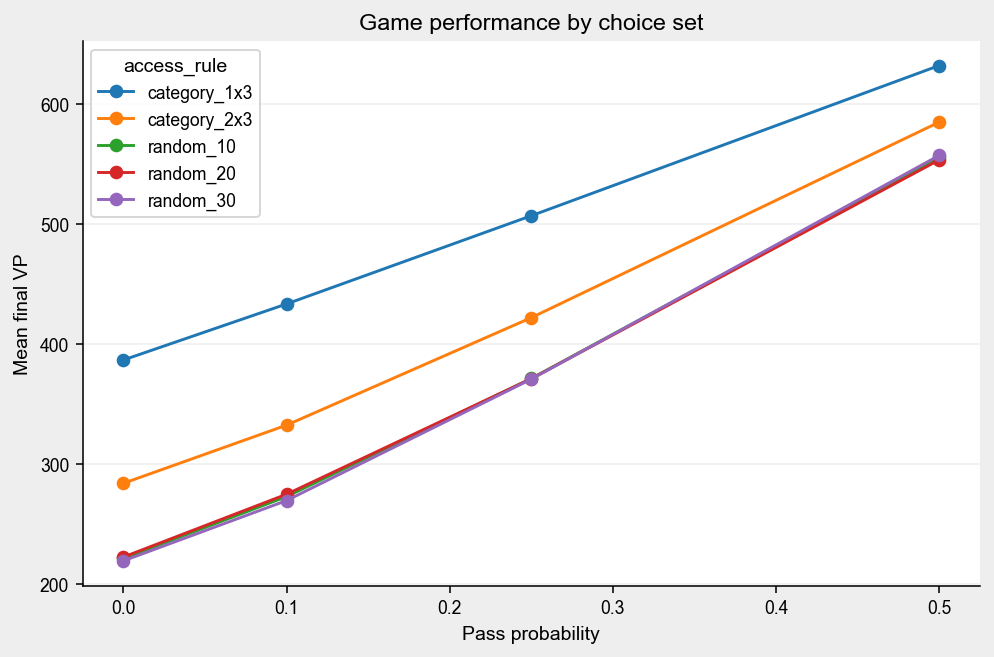

In [7]:
ax = vp_table.plot(marker="o")
ax.set_xlabel("Pass probability")
ax.set_ylabel("Mean final VP")
ax.set_title("Game performance by choice set")
ax.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()


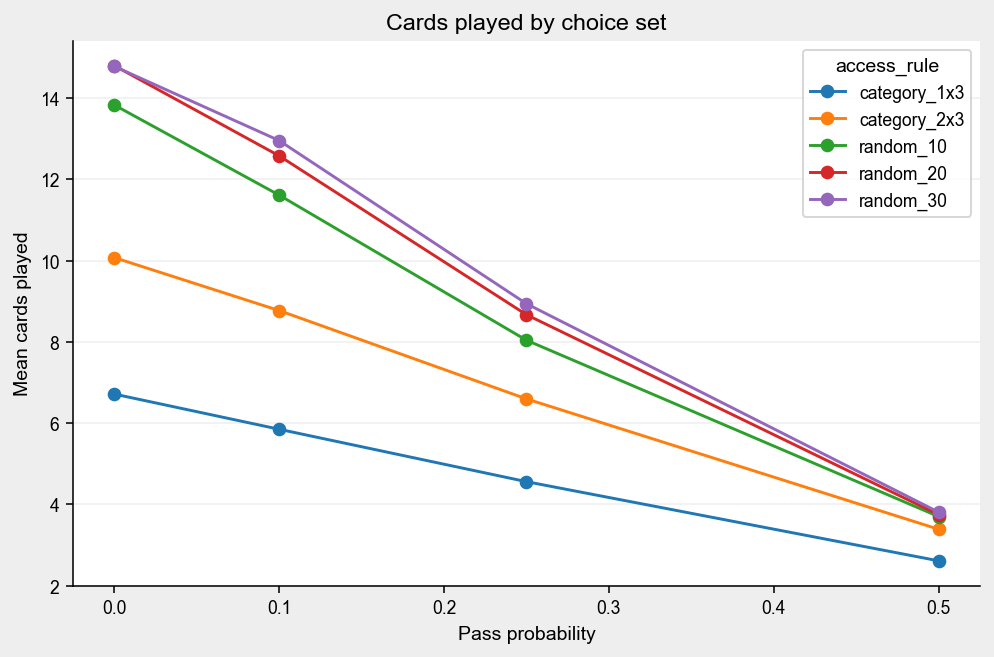

In [8]:
ax = cards_played_table.plot(marker="o")
ax.set_xlabel("Pass probability")
ax.set_ylabel("Mean cards played")
ax.set_title("Cards played by choice set")
ax.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()


## 4. Card analysis per experimental condition

Card metrics are calculated **within each of the 20 rule conditions**. Pooling all simulations first would confound technology performance with the rules controlling whether a card can be seen or played.

The result is cached because this is the expensive analysis step. The cache is automatically treated as stale when either combined simulation Parquet is newer than `card_results.parquet`.


In [9]:
cache_is_fresh = (
    CARD_RESULTS_PATH.exists()
    and CARD_RESULTS_PATH.stat().st_mtime
    >= max(
        GAMES_PATH.stat().st_mtime,
        PLAYS_PATH.stat().st_mtime,
    )
)

if cache_is_fresh and not RECALCULATE_CARD_RESULTS:

    card_results = pd.read_parquet(CARD_RESULTS_PATH)
    print("Loaded current cached card results.")

else:

    plays_by_experiment = {
        experiment: plays
        for experiment, plays in all_plays.groupby("experiment")
    }

    card_results = []

    for experiment, games in all_games.groupby("experiment"):

        print(experiment)

        result = card_analysis(
            games,
            plays=plays_by_experiment[experiment],
            game_data=game_data,
            elite_share=0.05,
        )

        result["experiment"] = experiment
        result["access_rule"] = games["access_rule"].iloc[0]
        result["pass_probability"] = games["pass_probability"].iloc[0]

        card_results.append(result)

    card_results = pd.concat(
        card_results,
        ignore_index=True,
    )

    card_results.to_parquet(
        CARD_RESULTS_PATH,
        index=False,
    )

    print("Card results recalculated and cached.")


Loaded current cached card results.


## 5. Card metrics

No single metric is treated as "the value of a card".

- **Occurrence:** share of games containing the card. Exposure, not effectiveness.
- **VP lift:** mean VP without card minus mean VP with card. Positive values are associated with better games.
- **Elite enrichment:** occurrence among the best 5% divided by occurrence in all games. Values above 1 mean overrepresentation among elite games.
- **Positive lift share:** share of rule conditions where VP lift is estimable and positive.
- **Enriched share:** share of conditions with elite enrichment above 1.
- **Selection rate:** selected / playable opportunities. Under the random strategy this primarily measures competition within the available choice set, not preference.
- **Mean round:** when the technology is typically played.

VP lift and enrichment are **associations**, not causal card effects.


## 6. Aggregate card robustness

The condition-level results are reduced to one row per logical card.

Category is retained explicitly so all card plots can use the same central color mapping.


In [10]:
# Ensure category information is present even if an older cached result
# was generated before category was added to card_analysis().
card_info = (
    pd.DataFrame(game_data["cards"])
    [["card_id", "label_en", "Slot/Stapel"]]
    .drop_duplicates("card_id")
    .rename(columns={
        "card_id": "card",
        "Slot/Stapel": "category",
    })
)

if "category" not in card_results.columns:
    card_results = card_results.merge(
        card_info,
        on=["card", "label_en"],
        how="left",
    )

card_results["round_weight"] = (
    card_results["mean_round"]
    * card_results["times_played"]
)

card_robustness = (
    card_results
    .groupby(["card", "label_en", "category"], dropna=False)
    .agg(
        conditions=("experiment", "nunique"),

        mean_occurrence=("occurrence", "mean"),
        min_occurrence=("occurrence", "min"),
        max_occurrence=("occurrence", "max"),

        mean_vp_lift=("vp_lift", "mean"),
        min_vp_lift=("vp_lift", "min"),
        max_vp_lift=("vp_lift", "max"),

        lift_estimable=("vp_lift", lambda x: x.notna().sum()),
        positive_lift_cases=("vp_lift", lambda x: (x > 0).sum()),

        mean_enrichment=("enrichment", "mean"),
        min_enrichment=("enrichment", "min"),
        max_enrichment=("enrichment", "max"),
        enriched_cases=("enrichment", lambda x: (x > 1).sum()),

        playable_opportunities=("playable_opportunities", "sum"),
        selected=("selected", "sum"),
        times_played=("times_played", "sum"),
        round_weight=("round_weight", "sum"),
    )
    .reset_index()
)

card_robustness["positive_lift_share"] = (
    card_robustness["positive_lift_cases"]
    / card_robustness["lift_estimable"].replace(0, pd.NA)
)

card_robustness["enriched_share"] = (
    card_robustness["enriched_cases"]
    / card_robustness["conditions"]
)

card_robustness["selection_rate"] = (
    card_robustness["selected"]
    / card_robustness["playable_opportunities"].replace(0, pd.NA)
)

card_robustness["mean_round"] = (
    card_robustness["round_weight"]
    / card_robustness["times_played"].replace(0, pd.NA)
)

card_robustness = card_robustness.sort_values(
    ["positive_lift_share", "mean_vp_lift"],
    ascending=False,
)

card_robustness.head()


,card,label_en,category,conditions,mean_occurrence,min_occurrence,max_occurrence,mean_vp_lift,min_vp_lift,max_vp_lift,...,max_enrichment,enriched_cases,playable_opportunities,selected,times_played,round_weight,positive_lift_share,enriched_share,selection_rate,mean_round
47,thermal_flexibility,Thermal flexibility,*Flexibilität,20,0.199872,0.008389,0.586358,211.429692,101.283863,371.559983,...,7.996646,20,120093,34516,34516,88926.0,1.0,1.0,0.287411,2.576370
45,shower_water_heat_recovery,Heat recovery from shower water,*Effizienz,20,0.106007,0.006607,0.275772,197.983487,78.260637,400.719606,...,9.837144,20,123067,18372,18372,59607.0,1.0,1.0,0.149285,3.244448
17,efficient_appliances,Efficient appliances,*Flexibilität,20,0.106978,0.007236,0.278613,189.451236,76.899807,330.033076,...,6.720422,20,122452,18547,18547,60325.0,1.0,1.0,0.151463,3.252548
14,decentralized_air_source_heat_pump,Decentralized air source heat pump,Wärmeerzeugung,20,0.124445,0.044883,0.195763,157.467400,46.976212,330.898161,...,5.932091,20,218751,21924,21924,46086.0,1.0,1.0,0.100224,2.102080
29,groundwater_heat_pump,Groundwater heat pump,Wärmeerzeugung,20,0.089980,0.037332,0.122151,142.561515,40.072195,304.807398,...,4.678403,20,191409,15910,15910,35646.0,1.0,1.0,0.083120,2.240478


## 7. Category strength

"Category strength" is defined here as the **unweighted average across logical cards** in the category. A category with many physical copies of one card therefore does not receive extra weight.

The summary is useful for identifying whether the model systematically favours one type of intervention.


In [11]:
category_summary = (
    card_robustness
    .groupby("category", dropna=False)
    .agg(
        cards=("card", "nunique"),
        mean_vp_lift=("mean_vp_lift", "mean"),
        median_vp_lift=("mean_vp_lift", "median"),
        mean_enrichment=("mean_enrichment", "mean"),
        mean_occurrence=("mean_occurrence", "mean"),
        mean_positive_lift_share=("positive_lift_share", "mean"),
        mean_selection_rate=("selection_rate", "mean"),
    )
    .reset_index()
)

category_summary.sort_values(
    "mean_vp_lift",
    ascending=False,
)


,category,cards,mean_vp_lift,median_vp_lift,mean_enrichment,mean_occurrence,mean_positive_lift_share,mean_selection_rate
8,Wärmeerzeugung,8,101.577835,129.271289,1.483242,0.085651,0.850000,0.075983
1,*Flexibilität,7,82.596268,47.019701,2.068722,0.232097,0.800000,0.202142
3,Abgabe,5,55.842599,59.852146,0.985062,0.089301,0.920000,0.162344
5,Dämmung,6,47.494620,40.278899,1.082036,0.105156,0.891667,0.089557
0,*Effizienz,6,46.887872,18.798080,1.621228,0.243059,0.716667,0.140235
6,Fenster,5,28.395187,25.177879,0.951801,0.127543,0.810000,0.094047
2,*Zufriedenheit,8,21.682923,15.739870,1.290058,0.194434,0.712500,0.106051
7,Lüftung,4,18.309901,12.544236,0.978866,0.149803,0.662500,0.100697
4,Dachnutzung,7,3.357133,3.570847,1.027322,0.094561,0.535714,0.081764


### Category mean versus individual technologies

Bars show the category mean. Dots show the individual logical cards within the category.

This is more informative than a category average alone: a strong mean driven by one exceptional technology is visibly different from a category where most cards perform consistently well.


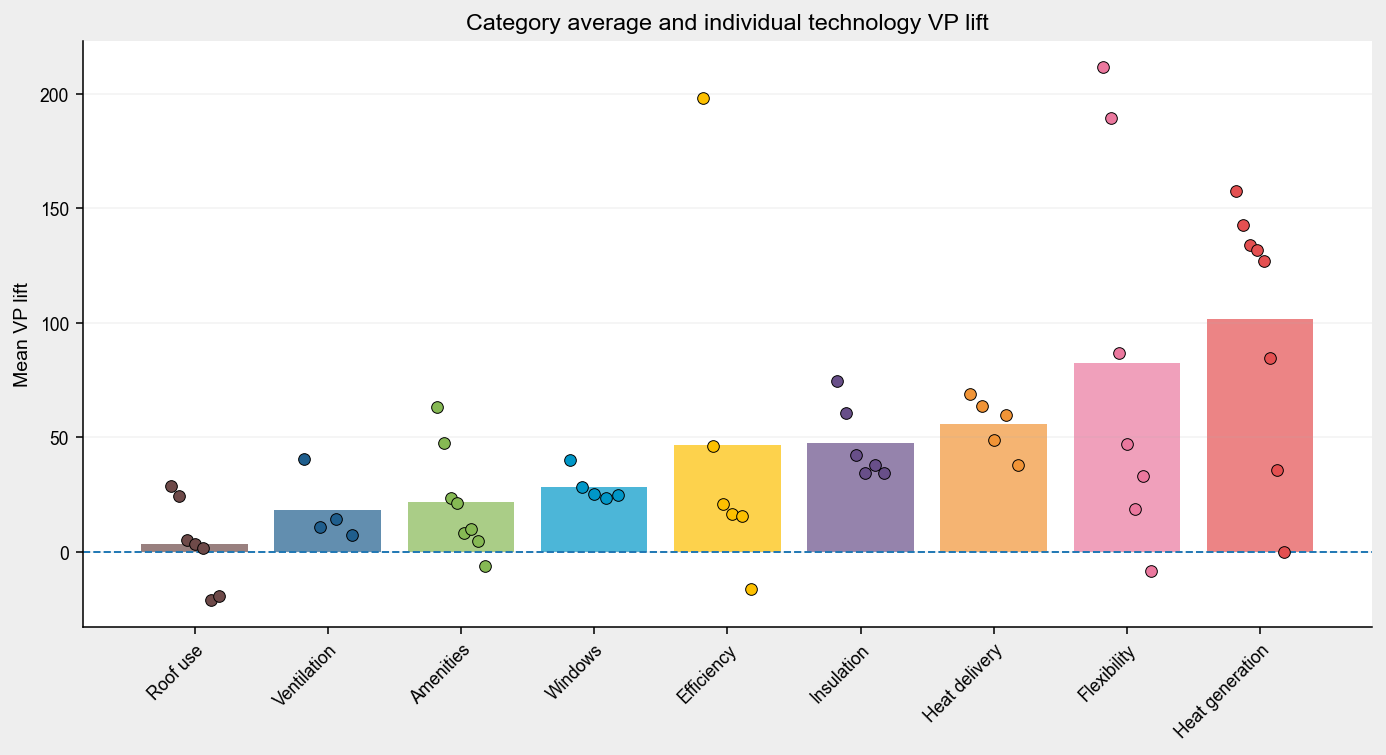

In [12]:
fig, ax = plot_category_strength(
    card_robustness,
    "mean_vp_lift",
    ylabel="Mean VP lift",
    title="Category average and individual technology VP lift",
    baseline=0,
)

if SAVE_FIGURES:
    save_figure(
        fig,
        FIGURE_DIR,
        "category_vp_lift.png",
    )

plt.show()


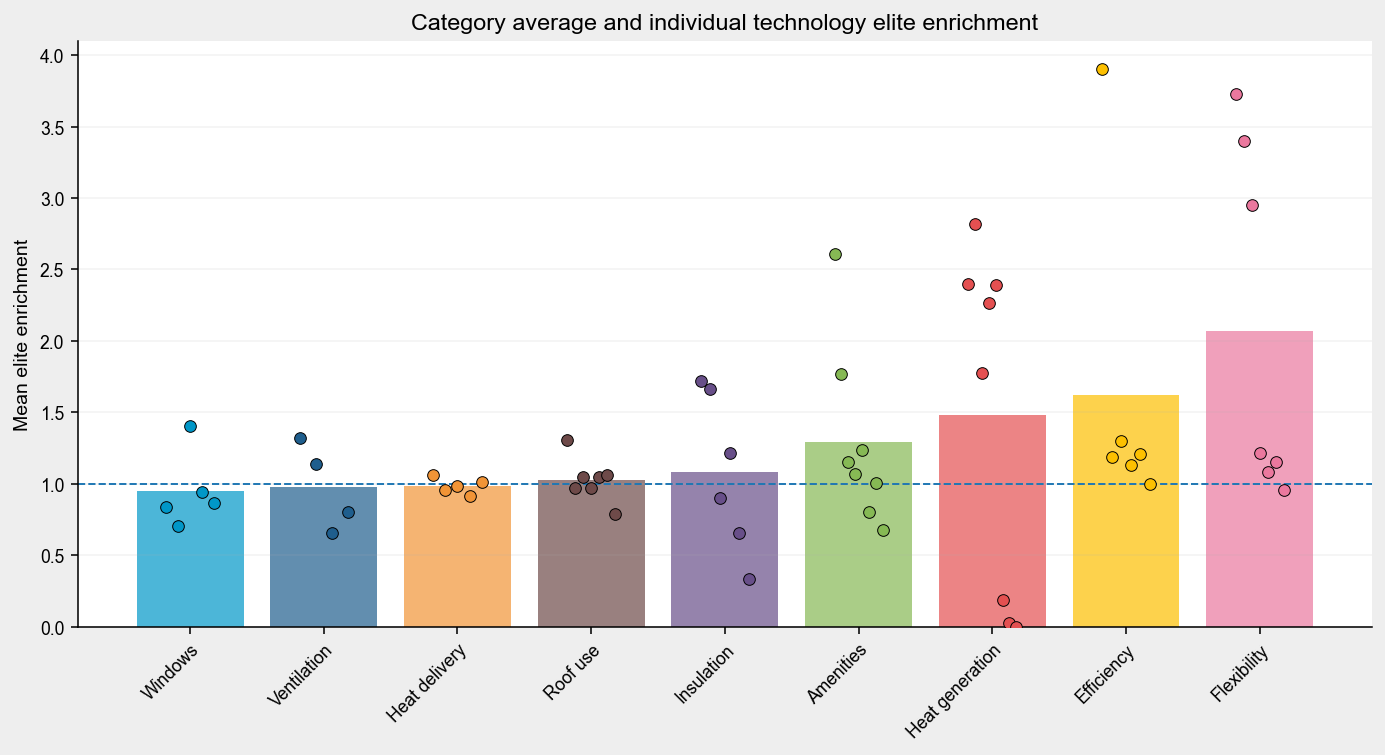

In [13]:
fig, ax = plot_category_strength(
    card_robustness,
    "mean_enrichment",
    ylabel="Mean elite enrichment",
    title="Category average and individual technology elite enrichment",
    baseline=1,
)

if SAVE_FIGURES:
    save_figure(
        fig,
        FIGURE_DIR,
        "category_enrichment.png",
    )

plt.show()


### Card strength relative to its own category

The following derived metric asks whether a technology performs better or worse than the average card in its own category:
```math
VP\ lift_{relative}
=
VP\ lift_{card}
-
\overline{VP\ lift}_{category}
```

Positive values indicate above-category performance.


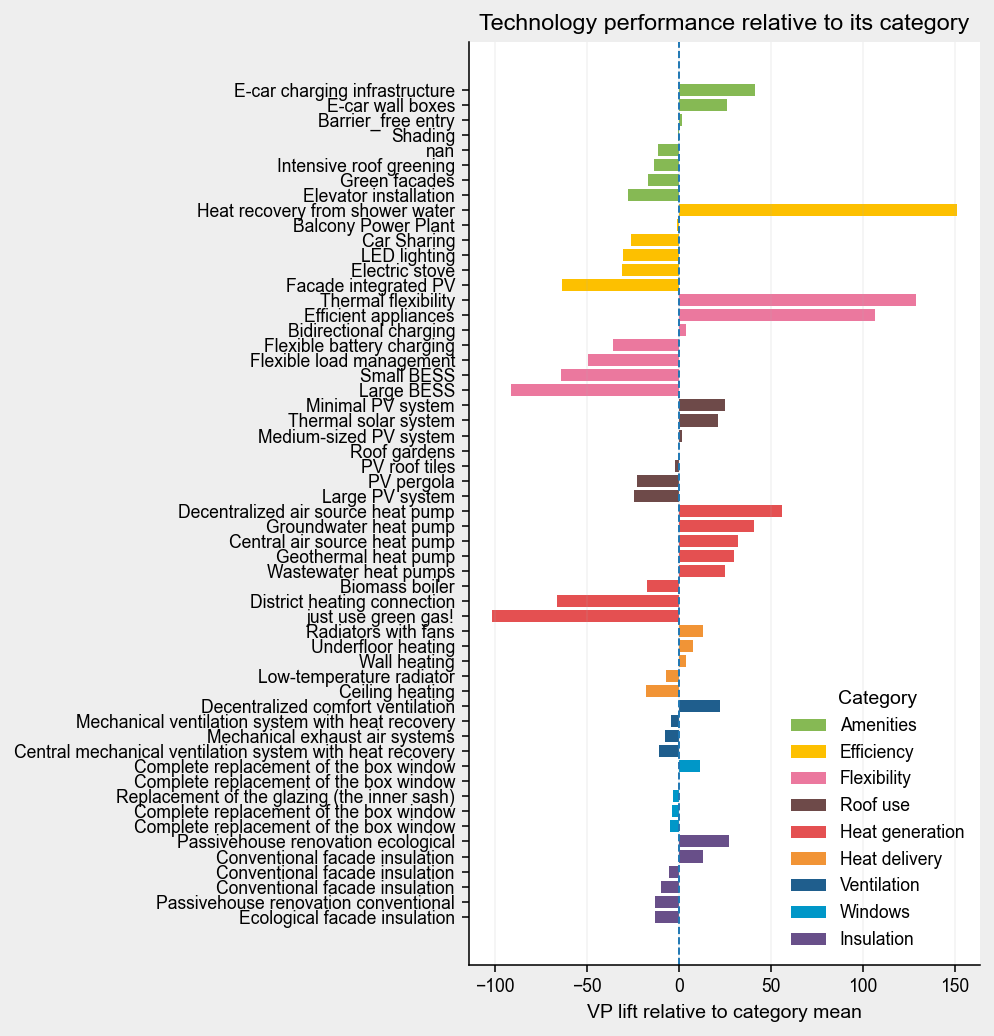

In [14]:
card_robustness["category_mean_vp_lift"] = (
    card_robustness
    .groupby("category")["mean_vp_lift"]
    .transform("mean")
)

card_robustness["vp_lift_vs_category"] = (
    card_robustness["mean_vp_lift"]
    - card_robustness["category_mean_vp_lift"]
)

fig, ax = plot_card_bars(
    card_robustness,
    "vp_lift_vs_category",
    ylabel="VP lift relative to category mean",
    title="Technology performance relative to its category",
    baseline=0,
    horizontal=True,
    group_by_category=True
)

plt.show()


## 8. Overall technology charts

All card names use a common 45° rotation and all points/bars use the central category colors.


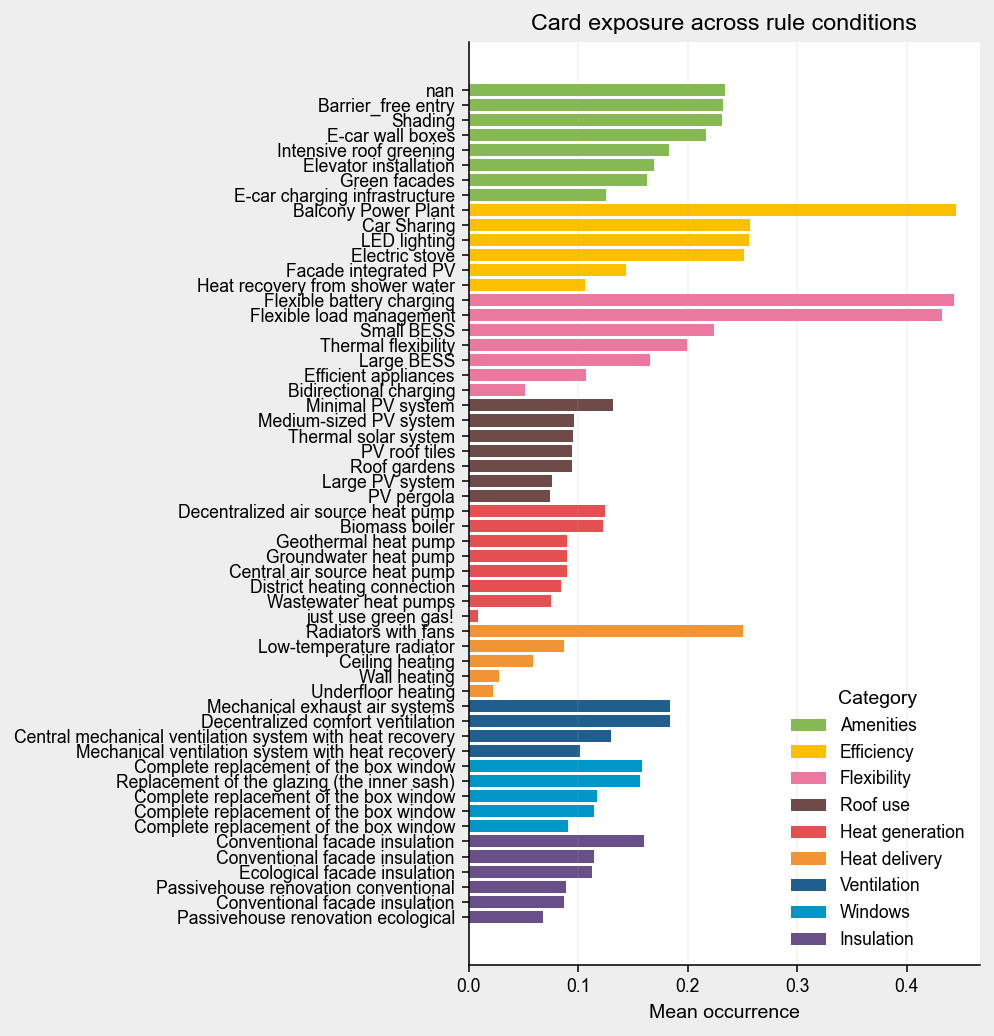

In [15]:
fig, ax = plot_card_bars(
    card_robustness,
    "mean_occurrence",
    ylabel="Mean occurrence",
    title="Card exposure across rule conditions",
    
    horizontal=True,
    group_by_category=True
)

plt.show()


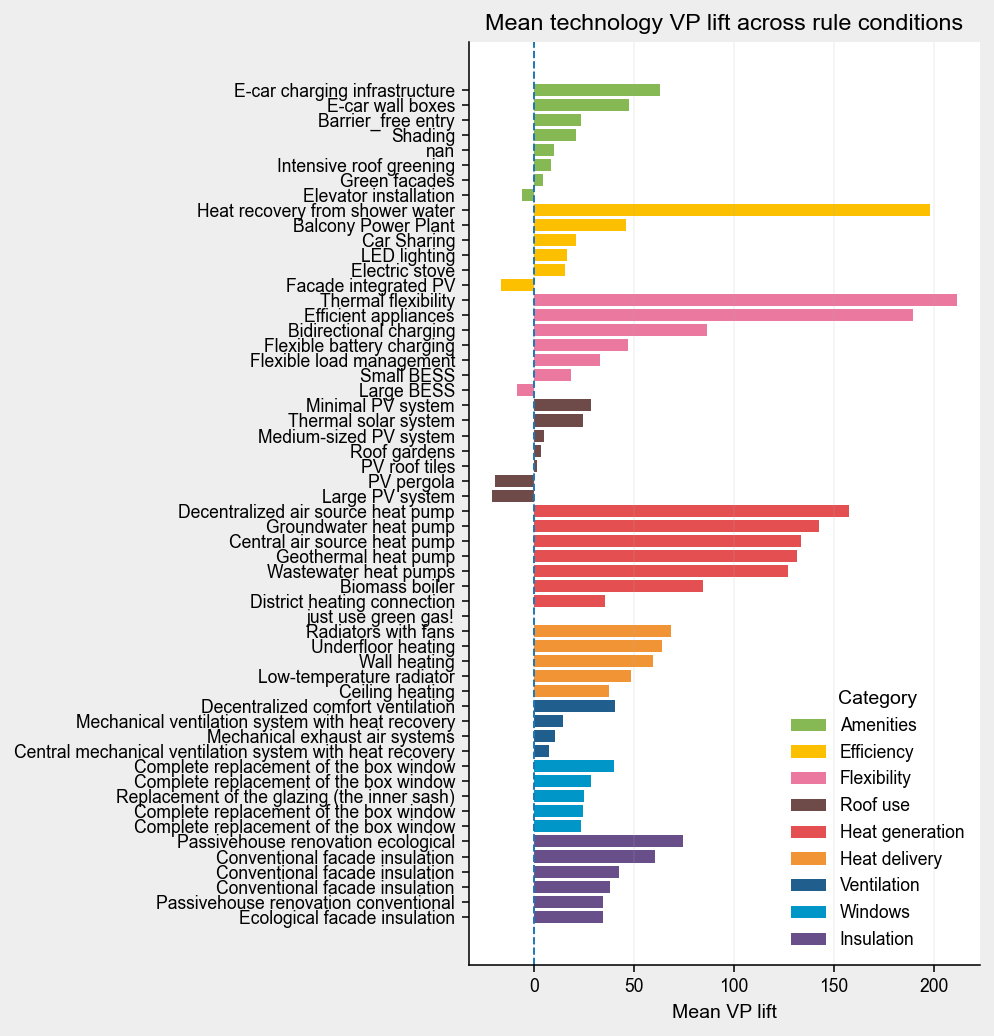

In [16]:
fig, ax = plot_card_bars(
    card_robustness,
    "mean_vp_lift",
    ylabel="Mean VP lift",
    title="Mean technology VP lift across rule conditions",
    baseline=0,
    horizontal=True,
    group_by_category=True
)

plt.show()


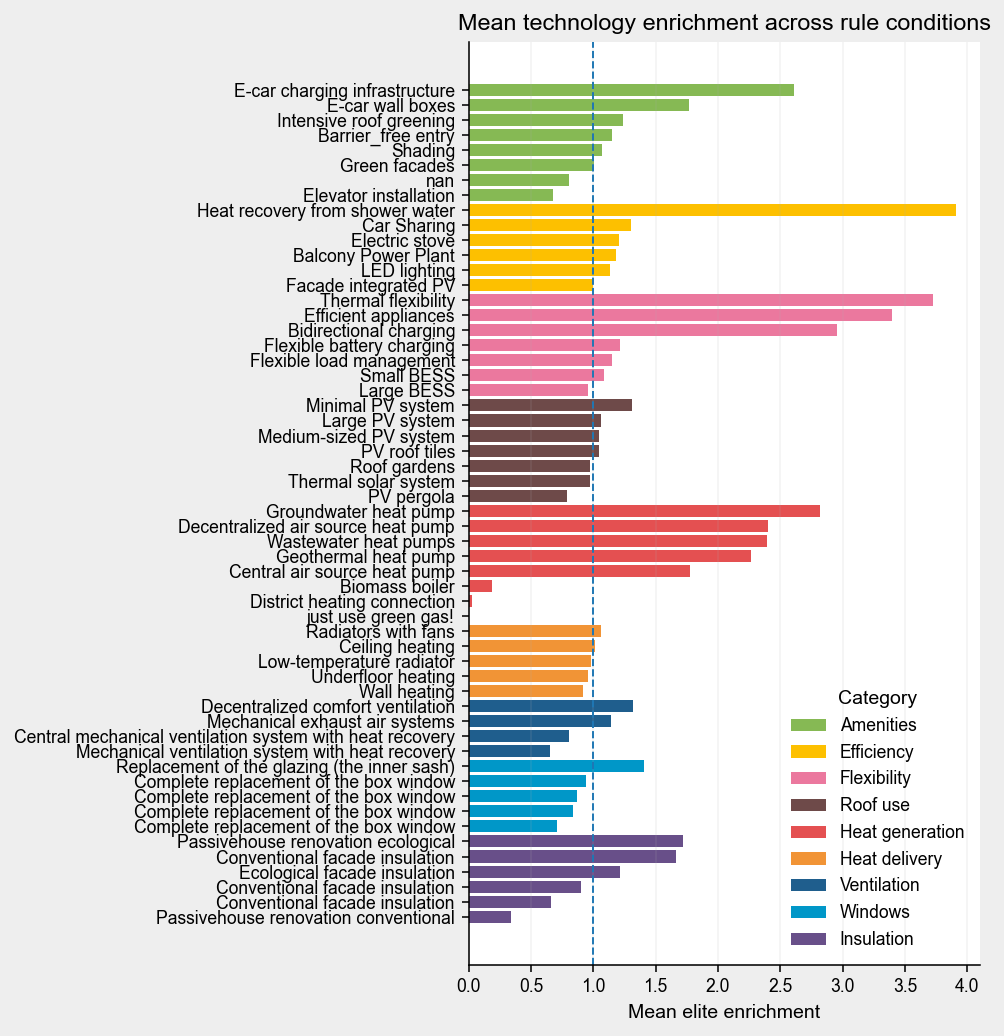

In [17]:
fig, ax = plot_card_bars(
    card_robustness,
    "mean_enrichment",
    ylabel="Mean elite enrichment",
    title="Mean technology enrichment across rule conditions",
    baseline=1,
)

plt.show()


### Agreement between VP lift and elite enrichment

The upper-right region is most convincing: positive VP lift and enrichment above 1.

To avoid turning the chart into unreadable text, only cards with at least 2% mean occurrence are labelled.


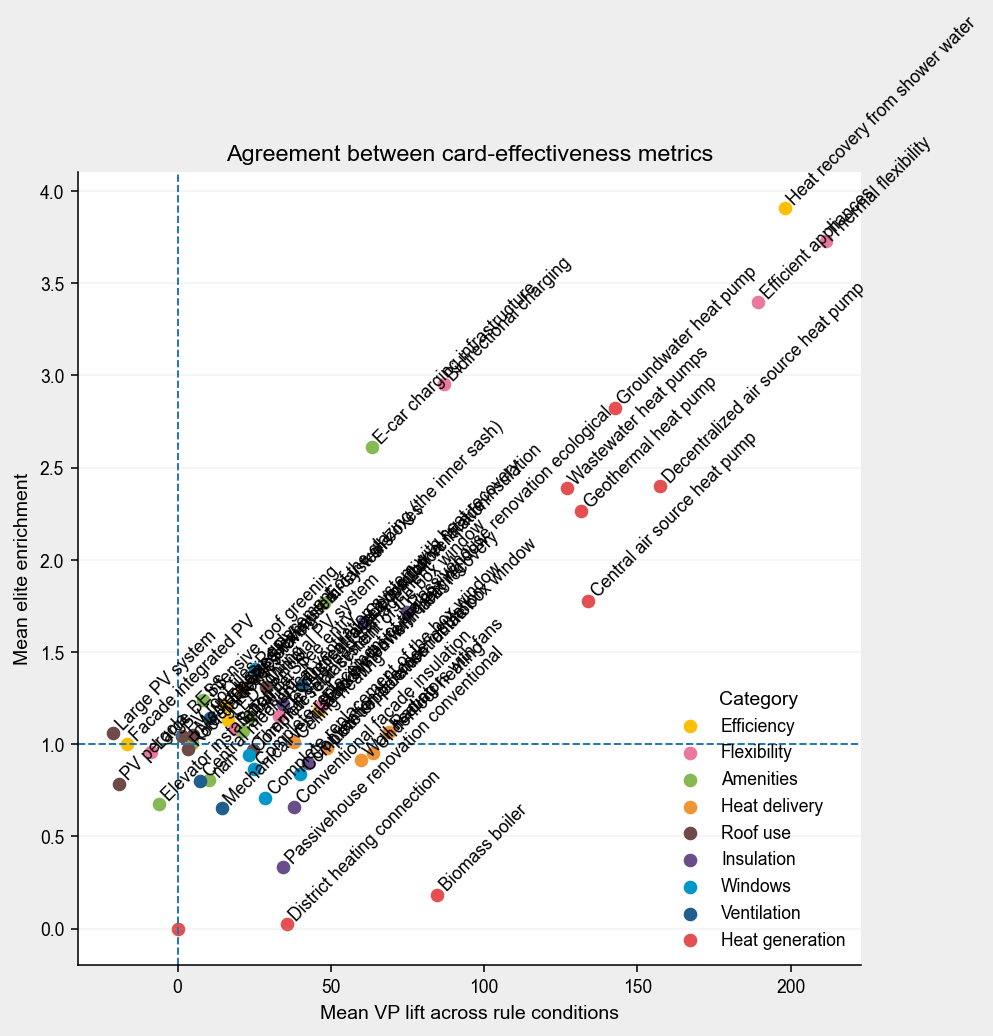

In [18]:
metric_plot = card_robustness.dropna(
    subset=["mean_vp_lift", "mean_enrichment"]
)

metric_labels = metric_plot.loc[
    metric_plot["mean_occurrence"] >= 0.02
]

fig, ax = plot_card_scatter(
    metric_plot,
    "mean_vp_lift",
    "mean_enrichment",
    xlabel="Mean VP lift across rule conditions",
    ylabel="Mean elite enrichment",
    title="Agreement between card-effectiveness metrics",
    labels=metric_labels,
    x_reference=0,
    y_reference=1,
)

plt.show()


### Exposure versus estimated strength

Extreme VP lift estimates among very rare cards are a warning sign that the comparison may be driven by sparse observations.


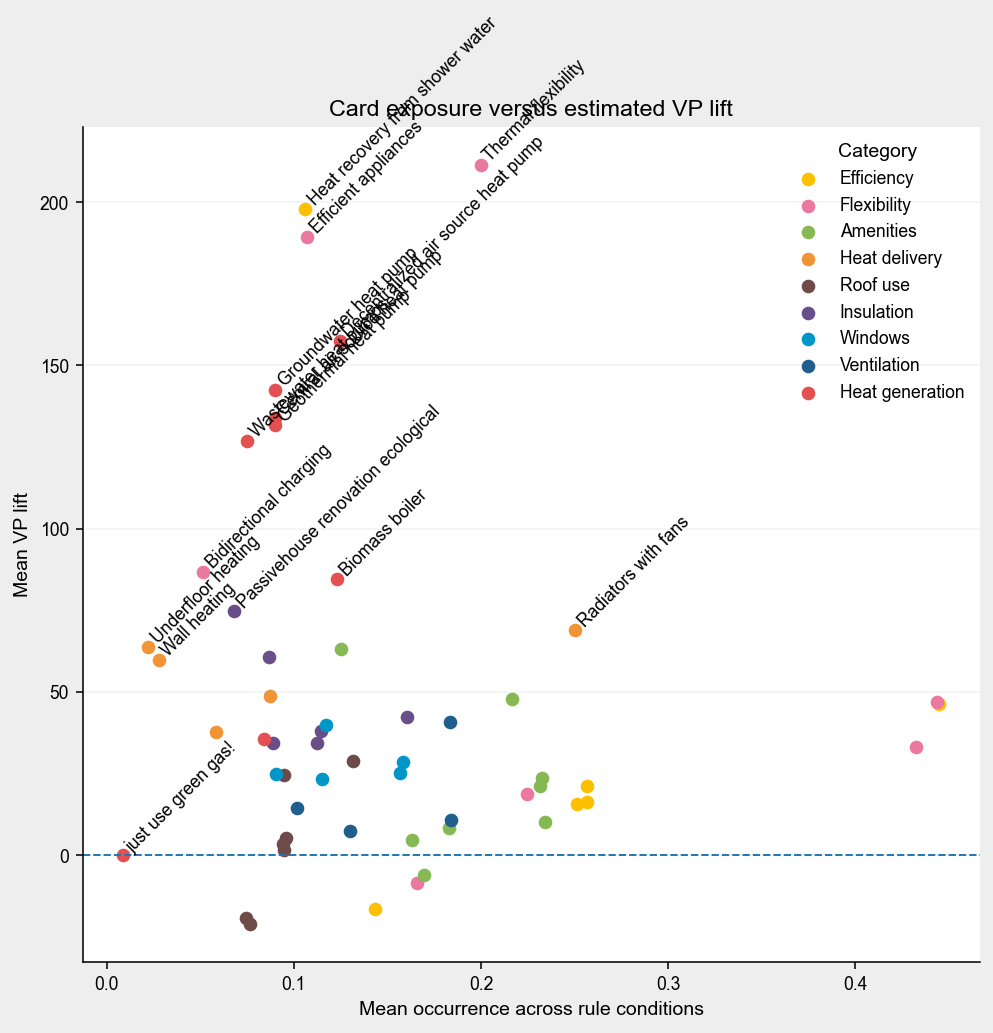

In [19]:
exposure_lift = card_robustness.dropna(
    subset=["mean_occurrence", "mean_vp_lift"]
)

label_threshold = (
    exposure_lift["mean_vp_lift"]
    .abs()
    .quantile(0.80)
)

exposure_labels = exposure_lift.loc[
    (exposure_lift["mean_occurrence"] < 0.05)
    | (exposure_lift["mean_vp_lift"].abs() >= label_threshold)
]

fig, ax = plot_card_scatter(
    exposure_lift,
    "mean_occurrence",
    "mean_vp_lift",
    xlabel="Mean occurrence across rule conditions",
    ylabel="Mean VP lift",
    title="Card exposure versus estimated VP lift",
    labels=exposure_labels,
    y_reference=0,
)

plt.show()


### Timing versus VP lift

Early technologies influence more later rounds and may unlock prerequisite chains. Timing therefore helps explain why some cards appear stronger than others.


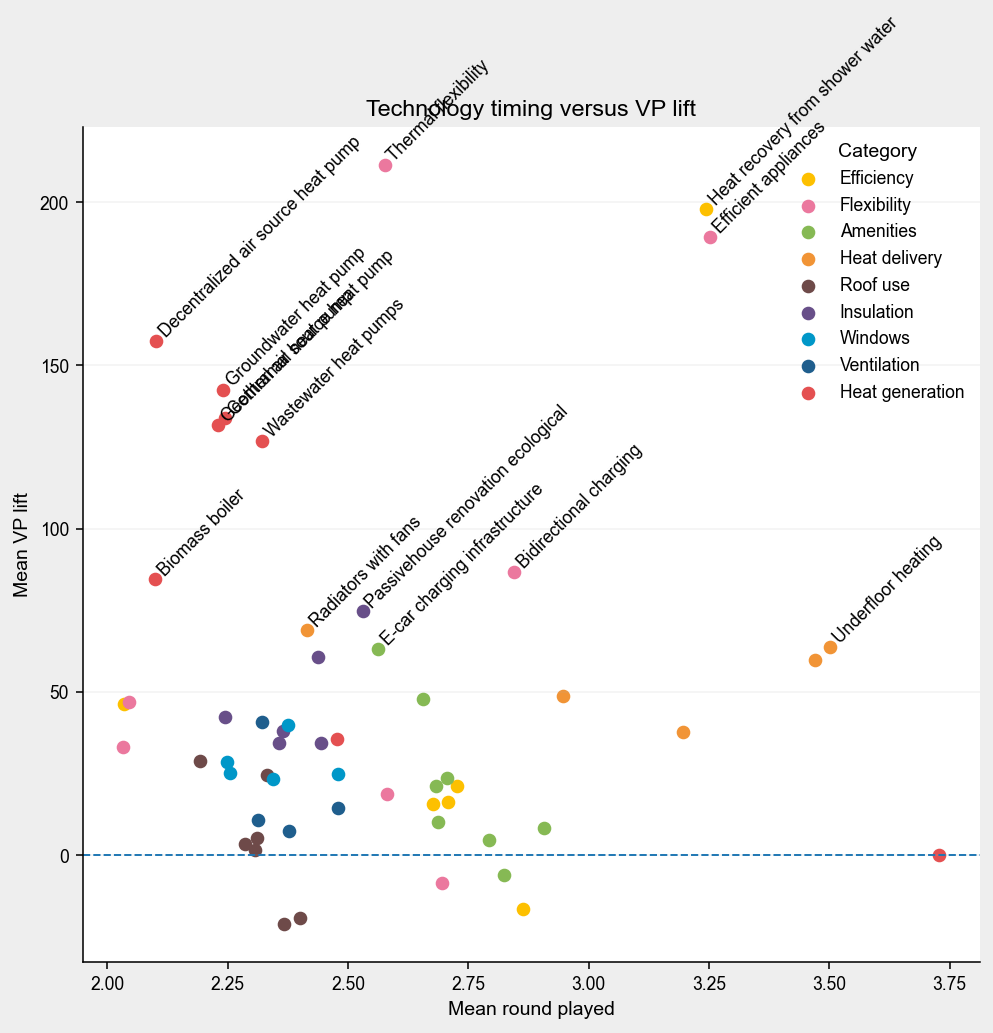

In [20]:
timing_plot = card_robustness.dropna(
    subset=["mean_round", "mean_vp_lift"]
)

timing_labels = timing_plot.loc[
    timing_plot["mean_vp_lift"].abs()
    >= timing_plot["mean_vp_lift"].abs().quantile(0.75)
]

fig, ax = plot_card_scatter(
    timing_plot,
    "mean_round",
    "mean_vp_lift",
    xlabel="Mean round played",
    ylabel="Mean VP lift",
    title="Technology timing versus VP lift",
    labels=timing_labels,
    y_reference=0,
)

plt.show()


## 9. Category-specific technology views

For publication or expert review it is often clearer to compare technologies only with their direct alternatives.

Set `SHOW_CATEGORY_CHARTS = True` to produce one uniformly formatted chart per category rather than one overloaded multi-panel figure.


In [21]:
SHOW_CATEGORY_CHARTS = False

if SHOW_CATEGORY_CHARTS:

    for category, category_cards in card_robustness.groupby("category"):

        fig, ax = plot_card_bars(
            category_cards,
            "mean_vp_lift",
            ylabel="Mean VP lift",
            title=f"{str(category).lstrip('*')}: technology VP lift",
            baseline=0,
            show_legend=False,
        )

        if SAVE_FIGURES:
            safe_category = (
                str(category)
                .replace("*", "")
                .replace(" ", "_")
                .replace("/", "_")
            )

            save_figure(
                fig,
                FIGURE_DIR,
                f"category_{safe_category}_vp_lift.png",
            )

        plt.show()


## 10. Compact card-metric table

The table deliberately retains several complementary metrics rather than collapsing them into one synthetic score.


In [22]:
card_metric_table = card_robustness[
    [
        "card",
        "label_en",
        "category",
        "mean_occurrence",
        "mean_vp_lift",
        "category_mean_vp_lift",
        "vp_lift_vs_category",
        "min_vp_lift",
        "max_vp_lift",
        "positive_lift_share",
        "mean_enrichment",
        "enriched_share",
        "selection_rate",
        "mean_round",
        "playable_opportunities",
        "times_played",
    ]
].copy()

card_metric_table


,card,label_en,category,mean_occurrence,mean_vp_lift,category_mean_vp_lift,vp_lift_vs_category,min_vp_lift,max_vp_lift,positive_lift_share,mean_enrichment,enriched_share,selection_rate,mean_round,playable_opportunities,times_played
47,thermal_flexibility,Thermal flexibility,*Flexibilität,0.199872,211.429692,82.596268,128.833424,101.283863,371.559983,1.00,3.726983,1.00,0.287411,2.576370,120093,34516
45,shower_water_heat_recovery,Heat recovery from shower water,*Effizienz,0.106007,197.983487,46.887872,151.095615,78.260637,400.719606,1.00,3.905890,1.00,0.149285,3.244448,123067,18372
17,efficient_appliances,Efficient appliances,*Flexibilität,0.106978,189.451236,82.596268,106.854968,76.899807,330.033076,1.00,3.398997,1.00,0.151463,3.252548,122452,18547
14,decentralized_air_source_heat_pump,Decentralized air source heat pump,Wärmeerzeugung,0.124445,157.467400,101.577835,55.889565,46.976212,330.898161,1.00,2.401077,1.00,0.100224,2.102080,218751,21924
29,groundwater_heat_pump,Groundwater heat pump,Wärmeerzeugung,0.089980,142.561515,101.577835,40.983680,40.072195,304.807398,1.00,2.820952,1.00,0.083120,2.240478,191409,15910
10,central_air_source_heat_pump,Central air source heat pump,Wärmeerzeugung,0.089736,133.800973,101.577835,32.223139,24.668376,305.204873,1.00,1.778567,1.00,0.083109,2.244926,190906,15866
25,geothermal_heat_pump,Geothermal heat pump,Wärmeerzeugung,0.089987,131.626847,101.577835,30.049012,29.774713,303.178140,1.00,2.265096,1.00,0.083013,2.230842,191620,15907
51,wastewater_heat_pump,Wastewater heat pumps,Wärmeerzeugung,0.074895,126.915732,101.577835,25.337898,26.415969,294.165112,1.00,2.389977,1.00,0.082129,2.321168,161806,13289
6,bidirectional_charging,Bidirectional charging,*Flexibilität,0.051658,86.792039,82.596268,4.195771,33.864109,200.571331,1.00,2.952052,1.00,0.303717,2.845766,29353,8915
30,insulation_passivehouse_eco,Passivehouse renovation ecological,Dämmung,0.068023,74.740058,47.494620,27.245438,18.526034,170.592854,1.00,1.717089,0.90,0.082580,2.530496,146524,12100


## 11. Inspect one technology

Change `CARD` once; the following cells show:

1. the assigned card values,
2. its condition-level card metrics,
3. VP lift across access/pass rules,
4. enrichment across access/pass rules,
5. occurrence across access/pass rules,
6. selection rate across access/pass rules.


In [23]:
print(*card_metric_table["card"], sep="\n")


thermal_flexibility
shower_water_heat_recovery
efficient_appliances
decentralized_air_source_heat_pump
groundwater_heat_pump
central_air_source_heat_pump
geothermal_heat_pump
wastewater_heat_pump
bidirectional_charging
insulation_passivehouse_eco
fan_assisted_radiators
ev_charging_infrastructure
conventional_facade_insulation_2
ev_wallboxes
balcony_pv
insulation_standard_fossil
decentralized_comfort_ventilation
pv_minimal
underfloor_heating
low_temperature_radiator
window_repl_passivehouse
window_repl_plastic
barrier_free_entry
wall_heating
insulation_standard_eco
solar_thermal
flexible_battery_charging
conventional_facade_insulation_1
shading
biomass_boiler
ceiling_heating
glazing_replacement
car_sharing
BESS_small
flexible_load_management
window_repl_wood_alu
mechanical_exhaust_air
window_repl_eco_passivehouse
led_lighting
electric_stove
district_heating_connection
insulation_passivehouse_fossil
intensive_roof_greening
pv_medium
roof_garden
ventilation_heat_recovery
add_balcony
green

In [24]:
CARD = "green_gas"

card_definition = (
    pd.DataFrame(game_data["cards"])
    .loc[lambda df: df["card_id"] == CARD]
    .drop_duplicates("card_id")
)

card_definition.T


,54
Name,Grünes Gas
Slot/Stapel,Wärmeerzeugung
Count,1
Heizsystem,GG
Kosten,2
BauEmissionen,0
SofortCO2,0
Strombedarf,0
Stromproduktion,0
Stromspeicher,0


In [25]:
card_detail = (
    card_results.loc[
        card_results["card"] == CARD,
        [
            "access_rule",
            "pass_probability",
            "occurrence",
            "elite_occurrence",
            "enrichment",
            "vp_lift",
            "vp_lift_ci_low",
            "vp_lift_ci_high",
            "selection_rate",
            "mean_round",
            "playable_opportunities",
            "times_played",
        ],
    ]
    .sort_values(["access_rule", "pass_probability"])
)

card_detail


,access_rule,pass_probability,occurrence,elite_occurrence,enrichment,vp_lift,vp_lift_ci_low,vp_lift_ci_high,selection_rate,mean_round,playable_opportunities,times_played
55,category_1x3,0.00,0.010182,0.0,0.0,-6.090949,-29.026885,16.844987,0.062838,3.784946,1480,93
111,category_1x3,0.10,0.007727,0.0,0.0,18.781285,-9.110506,46.673077,0.044767,3.845070,1586,71
167,category_1x3,0.25,0.004606,0.0,0.0,76.097981,38.007774,114.188188,0.025919,3.906977,1659,43
223,category_1x3,0.50,0.001258,0.0,0.0,194.070419,118.408659,269.732178,0.006857,3.916667,1750,12
279,category_2x3,0.00,0.013192,0.0,0.0,-58.476359,-75.797265,-41.155453,0.040938,3.700855,2858,117
335,category_2x3,0.10,0.011942,0.0,0.0,-31.115498,-50.394619,-11.836377,0.033209,3.710280,3222,107
391,category_2x3,0.25,0.009201,0.0,0.0,31.527612,6.895696,56.159528,0.023096,3.797619,3637,84
447,category_2x3,0.50,0.003943,0.0,0.0,168.229717,132.839742,203.619691,0.009645,3.837838,3836,37
503,random_10,0.00,0.011572,0.0,0.0,-91.040789,-111.930402,-70.151175,0.019546,3.525253,5065,99
559,random_10,0.10,0.013358,0.0,0.0,-90.316782,-111.010667,-69.622897,0.019436,3.600000,5917,115


C:\Users\schneids\AppData\Local\Temp\ipykernel_27304\2522087301.py:65: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(right=0.84)


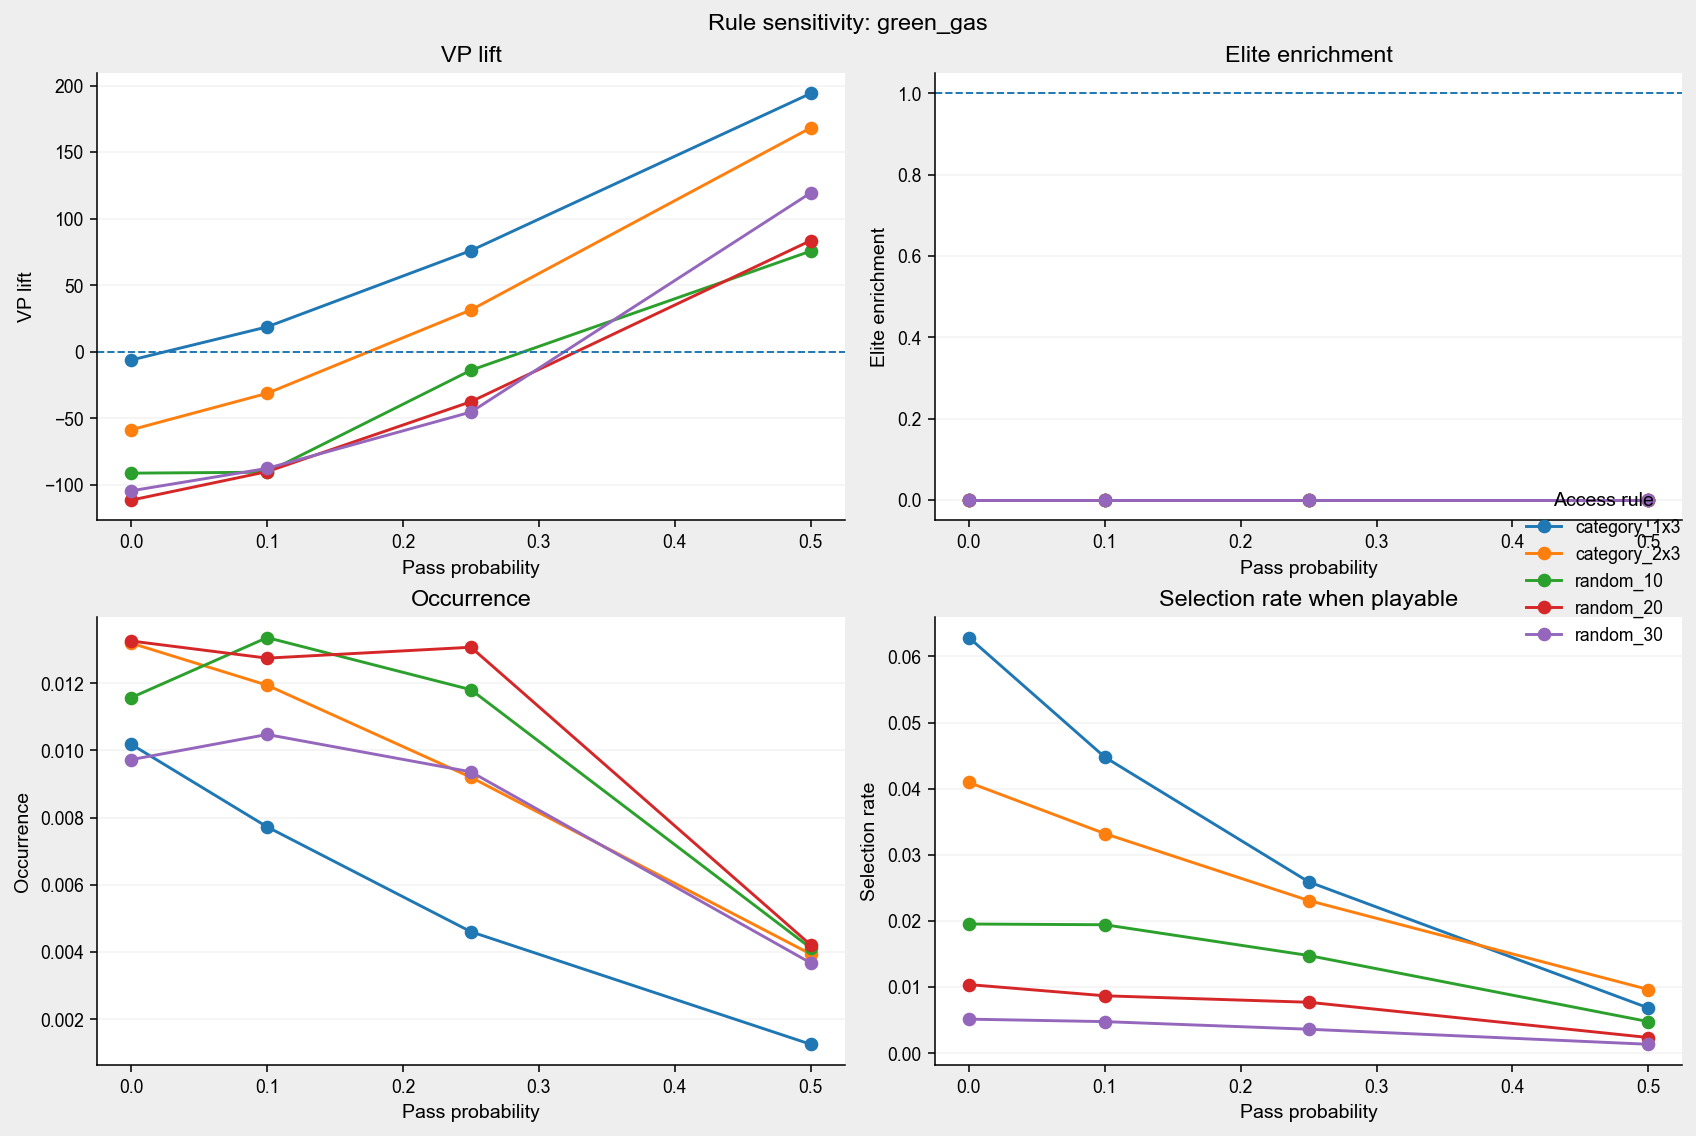

In [26]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 8),
    constrained_layout=True,
)

plot_rule_metric(
    card_results,
    CARD,
    "vp_lift",
    ylabel="VP lift",
    title="VP lift",
    reference=0,
    ax=axes[0, 0],
    show_legend=False,
)

plot_rule_metric(
    card_results,
    CARD,
    "enrichment",
    ylabel="Elite enrichment",
    title="Elite enrichment",
    reference=1,
    ax=axes[0, 1],
    show_legend=False,
)

plot_rule_metric(
    card_results,
    CARD,
    "occurrence",
    ylabel="Occurrence",
    title="Occurrence",
    ax=axes[1, 0],
    show_legend=False,
)

plot_rule_metric(
    card_results,
    CARD,
    "selection_rate",
    ylabel="Selection rate",
    title="Selection rate when playable",
    ax=axes[1, 1],
    show_legend=False,
)

# One common legend
handles, labels = axes[0, 0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="Access rule",
    loc="center right",
    frameon=False,
)

fig.suptitle(
    f"Rule sensitivity: {CARD}",
)

fig.subplots_adjust(right=0.84)

plt.show()


### Final VP with and without the technology in one rule condition

Do this comparison **within one experiment**, not across pooled conditions.

The distributions remain descriptive: a game that contains the technology may differ systematically in many other cards and states.


### Technologies that co-occur with the selected card

Within the selected experiment, compare:

\[
\frac{P(other\ card \mid CARD)}
     {P(other\ card)}
\]

Values above 1 indicate cards that appear disproportionately often in games containing the selected technology. This is useful for detecting prerequisite chains and technology combinations, but is not itself evidence of synergy.


## 12. Inspect individual simulated games

For debugging or qualitative interpretation, select all completed games containing one card and then inspect the complete decision trajectory of a specific game.


In [30]:
games_with_card = all_games.loc[
    all_games["played_cards"].apply(
        lambda cards: CARD in cards
    )
]

games_with_card[
    [
        "experiment",
        "game_id",
        "vp",
        "budget",
        "n_cards_played",
        "played_cards",
    ]
].sort_values("vp")


,experiment,game_id,vp,budget,n_cards_played,played_cards
134414,random_20_pass_0.1,4414,98,0,12,"[BESS_small, balcony_pv, conventional_facade_i..."
124414,random_20_pass_0,4414,98,0,12,"[BESS_small, balcony_pv, conventional_facade_i..."
86059,random_10_pass_0,6059,116,1,16,"[BESS_small, add_balcony, balcony_pv, bidirect..."
96059,random_10_pass_0.1,6059,116,1,16,"[BESS_small, add_balcony, balcony_pv, bidirect..."
162822,random_30_pass_0,2822,125,0,11,"[balcony_pv, electric_stove, ev_wallboxes, fan..."
...,...,...,...,...,...,...
186938,random_30_pass_0.25,6938,689,0,5,"[flexible_battery_charging, green_gas, insulat..."
10632,category_1x3_pass_0.1,632,695,5,8,"[balcony_pv, barrier_free_entry, fan_assisted_..."
6933,category_1x3_pass_0,6933,699,4,6,"[add_balcony, conventional_facade_insulation_1..."
145239,random_20_pass_0.25,5239,706,2,9,"[BESS_large, add_balcony, barrier_free_entry, ..."


In [31]:
GAME_ID = 151
GAME_EXPERIMENT = "random_20_pass_0.25"

all_plays.loc[
    (all_plays["game_id"] == GAME_ID)
    & (all_plays["experiment"] == GAME_EXPERIMENT)
].sort_values("action")


,game_id,seed,strategy,rule,draw_n,category_count,cards_per_category,pass_probability,round,turn,...,offered_cards,playable_cards,vp_before,budget_before,chosen_card,passed,vp_after_card,budget_after_card,experiment,access_rule


(<Figure size 1680x1260 with 2 Axes>,
 <Axes: title={'center': 'Technology VP lift across rule conditions'}>)

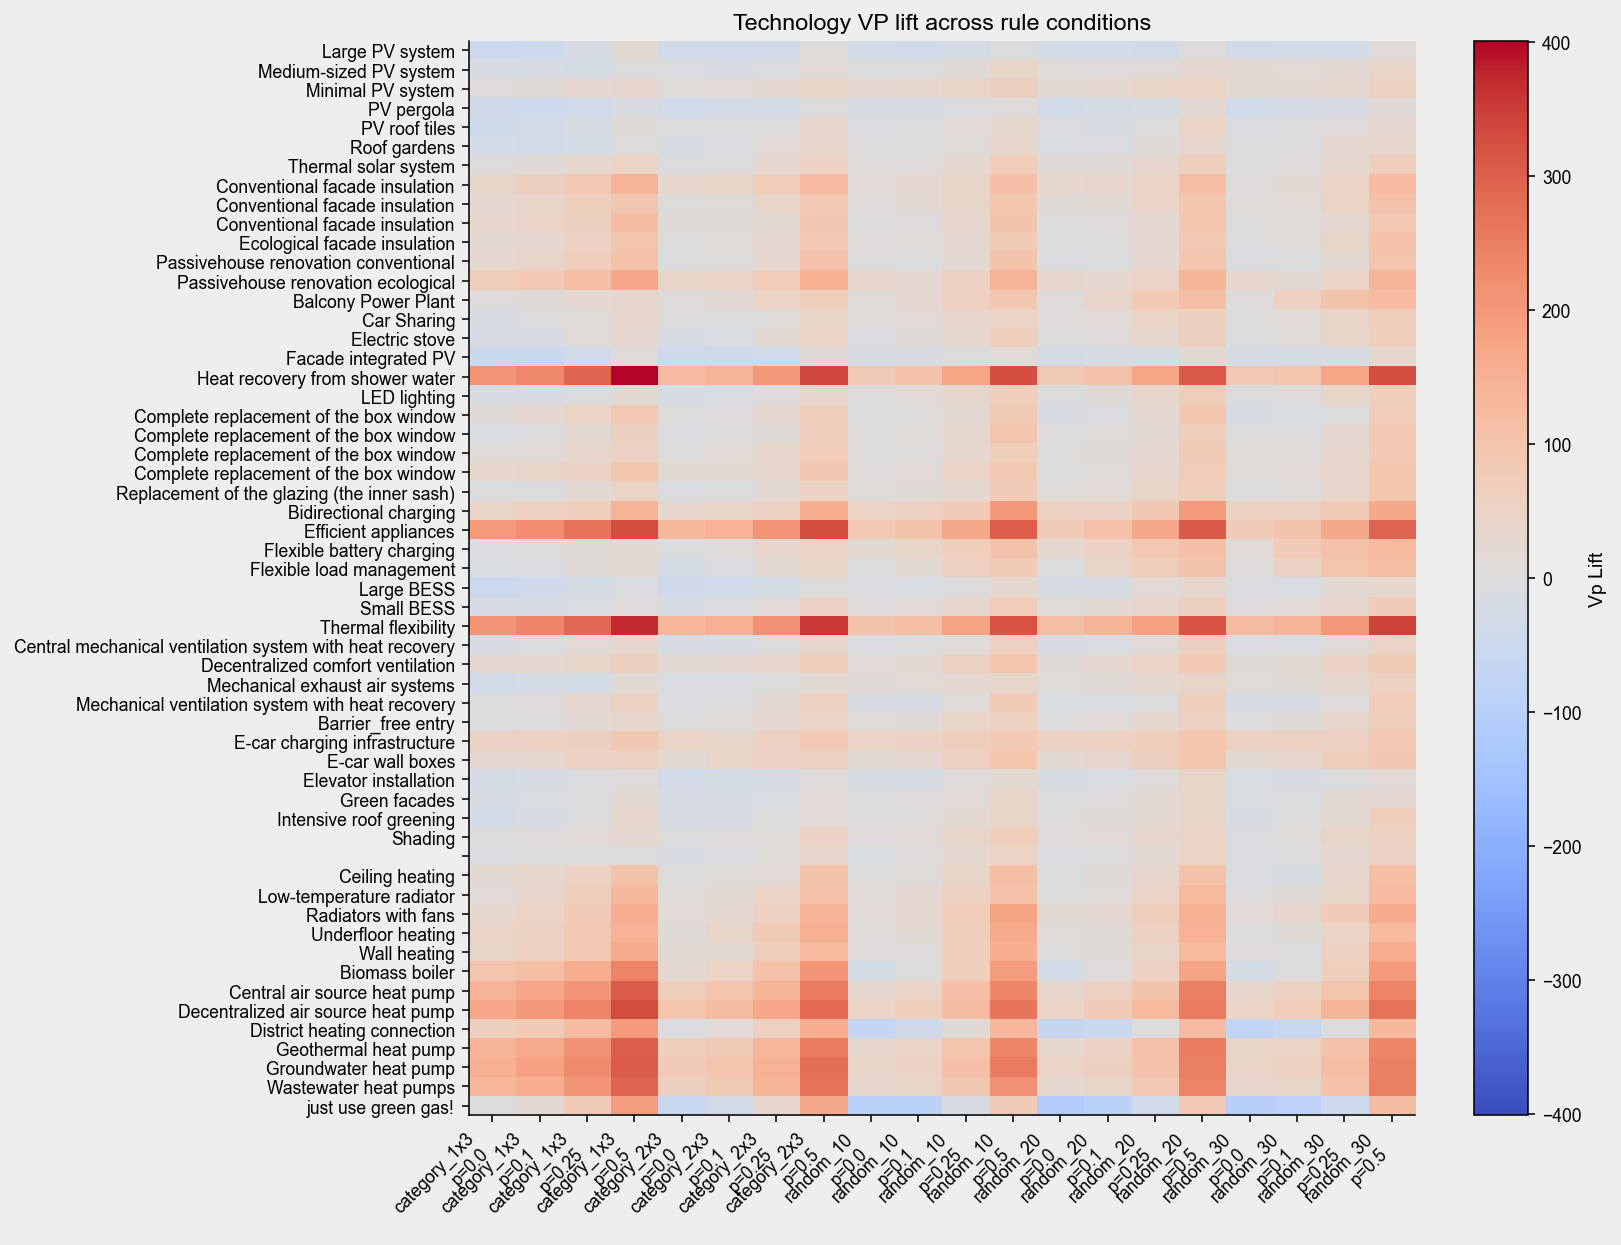

In [ ]:

plot_card_metric_heatmap(
    card_results,
    metric="vp_lift",
    title="Technology VP lift across rule conditions",
    center=0, 
    vmax=200,
    vmin=-200

)

(<Figure size 1680x1260 with 2 Axes>,
 <Axes: title={'center': 'Elite enrichment across rule conditions'}>)

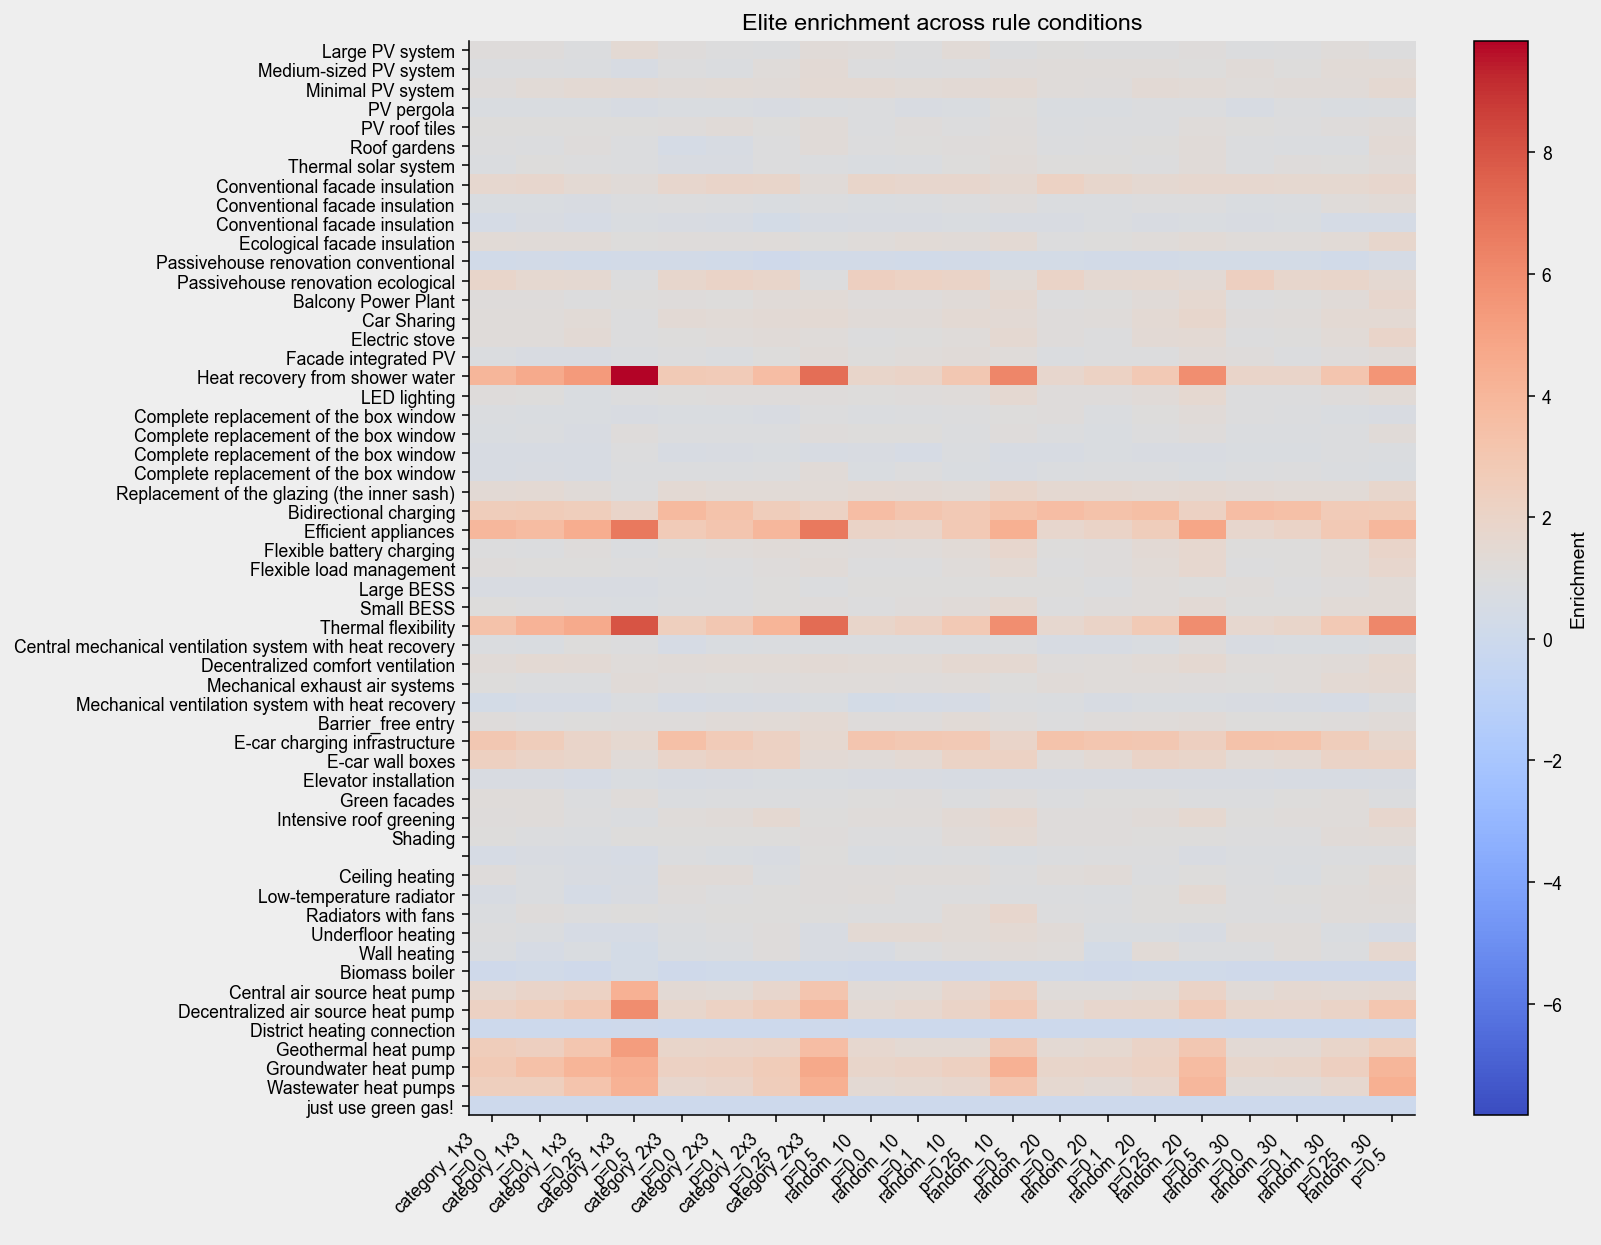

In [33]:
plot_card_metric_heatmap(
    card_results,
    metric="enrichment",
    title="Elite enrichment across rule conditions",
    center=1
)

## 13. Interpretation checklist

For the formal investigation:

1. **Completion:** do rules change the probability of surviving all rounds?
2. **Rule effect:** does broader card access improve final VP for the same passing behaviour?
3. **Cards played:** are outcome differences mainly explained by how many measures are installed?
4. **Category strength:** are entire categories systematically stronger or weaker?
5. **Within-category variation:** is a category average representative, or driven by individual cards?
6. **Occurrence:** is a card observed frequently enough for meaningful comparison?
7. **VP lift:** is card presence associated with better final VP?
8. **Elite enrichment:** is the card disproportionately represented in the best games?
9. **Rule robustness:** do those associations persist across the 20 rule conditions?
10. **Timing and co-occurrence:** can prerequisites, early play, or technology combinations explain apparent strength?

The next methodological extension, if required, would be strategy sensitivity or counterfactual continuation simulations. These should only be added if the descriptive rule-robustness analysis leaves important card effects ambiguous.


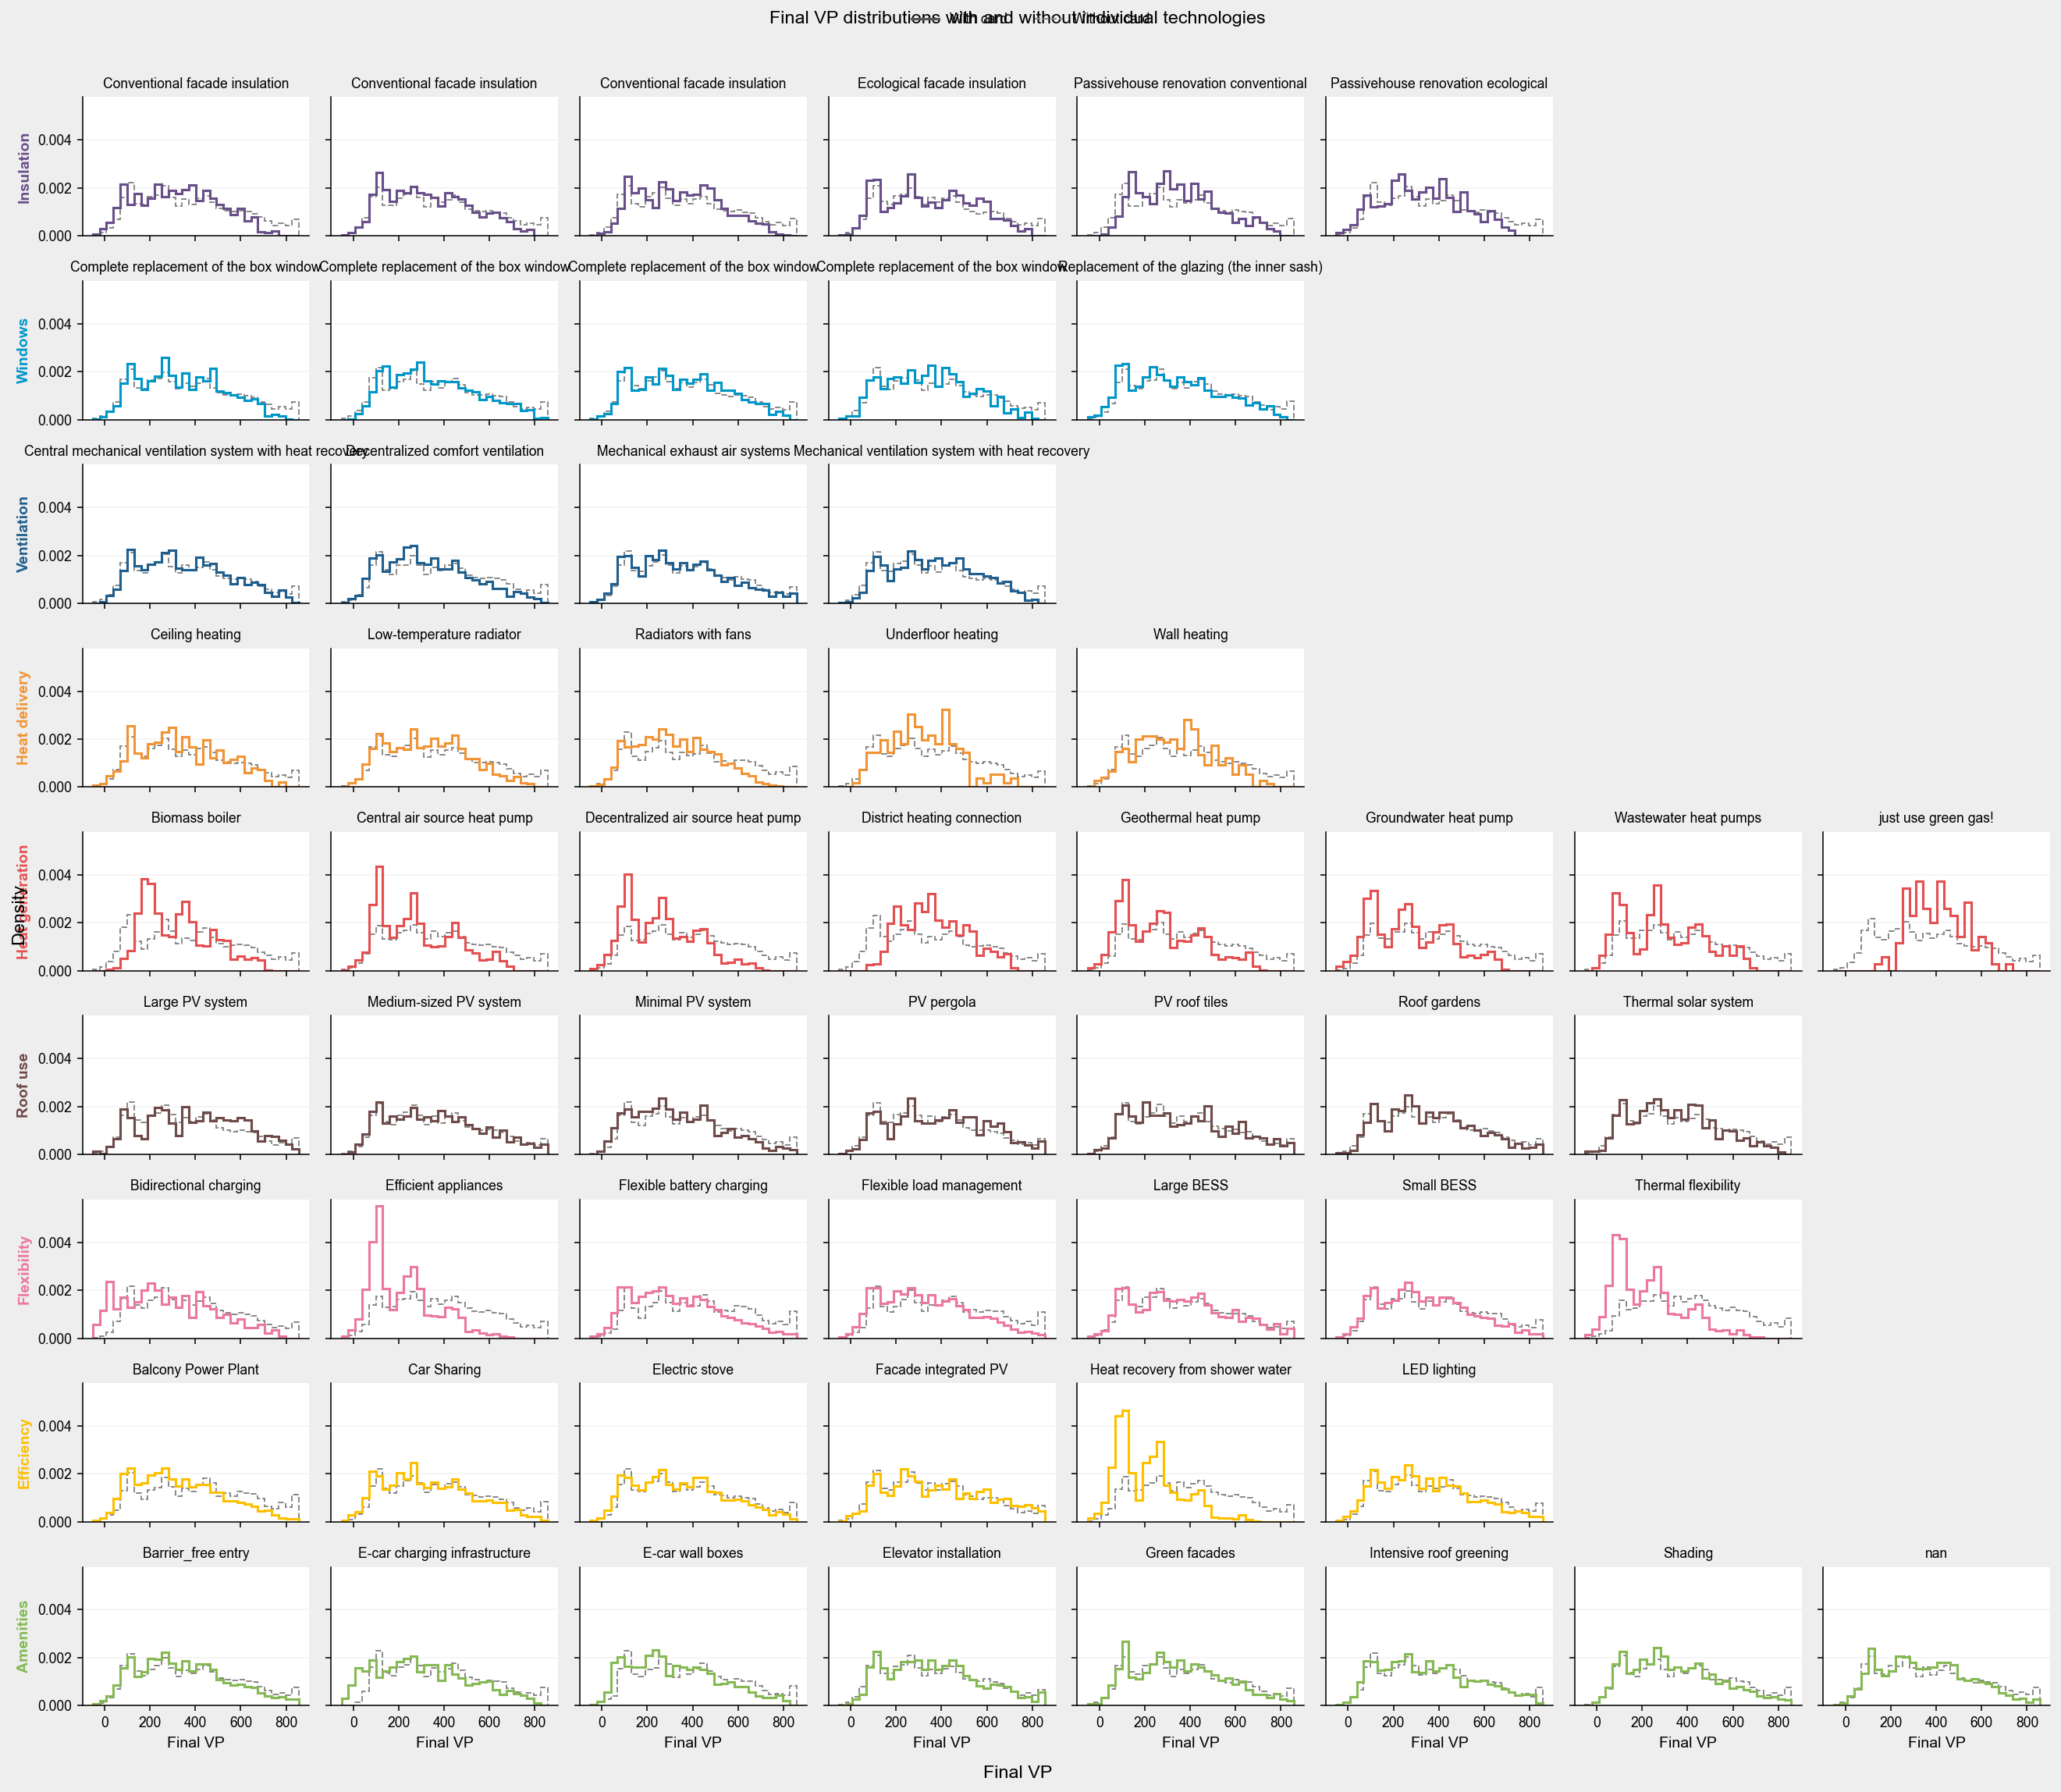

In [ ]:
EXPERIMENT = "random_20_pass_0.25"

games_condition = all_games.loc[
    all_games["experiment"] == EXPERIMENT
]

fig, axes = plot_vp_with_without_facets(
    games_condition,
    card_robustness,
)

plt.show()